In [35]:
!pip install transformers[torch] scikit-learn
import pandas as pd
from transformers import pipeline
from sklearn.metrics import accuracy_score, f1_score

In [36]:
# Load the labeled dataset
df = pd.read_csv('Products_review_data.csv')
# Verify the data structure
print(f"Total reviews to process: {len(df)}")
df.head()

Total reviews to process: 1000


,ReviewID,ProductID,UserID,Rating,ReviewText,ReviewDate
0,REV2000,Product_E,User_114,4,fantastic. wonderful experience.,4/17/2023
1,REV2001,Product_C,User_186,2,broke easily. awful.,11/27/2023
2,REV2002,Product_E,User_101,3,met expectations. five stars.,12/10/2023
3,REV2003,Product_A,User_175,5,very satisfied. wonderful experience.,11/10/2023
4,REV2004,Product_C,User_158,1,worst purchase. one star.,5/25/2024


In [37]:
# Create a classifier.
# We use a model fine-tuned on 3-class sentiment (Positive, Neutral, Negative)
model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# 'device=0' enables GPU acceleration for efficient batching
classifier = pipeline("sentiment-analysis", model=model_name, device=0)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
# Convert text column to a list and run through the model
texts = df['ReviewText'].tolist()
# Run the classifier with batch processing
# 'truncation=True' handles reviews that are too long for the model
results = classifier(texts, truncation=True, batch_size=32)

# Extract labels and scores back into the dataframe
df['predicted_sentiment'] = [res['label'].capitalize() for res in results]
df['confidence_score'] = [res['score'] for res in results]

In [39]:
def map_rating_to_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

# Create the missing column
df['true_label'] = df['Rating'].apply(map_rating_to_sentiment)

In [40]:
# Evaluation
acc = accuracy_score(df['true_label'], df['predicted_sentiment'])
f1 = f1_score(df['true_label'], df['predicted_sentiment'], average='weighted')

print(f"Final Accuracy: {acc:.2%}")
print(f"Final F1-Score: {f1:.4f}")

# Export to CSV for deliverable
df.to_csv('final_sentiment_output.csv', index=False)

Final Accuracy: 79.60%
Final F1-Score: 0.7283


In [41]:
# Select only the required columns for output
output_df = df[['ReviewText', 'predicted_sentiment', 'confidence_score']]

# Export to CSV
output_df.to_csv('Task-8_Output.csv', index=False)


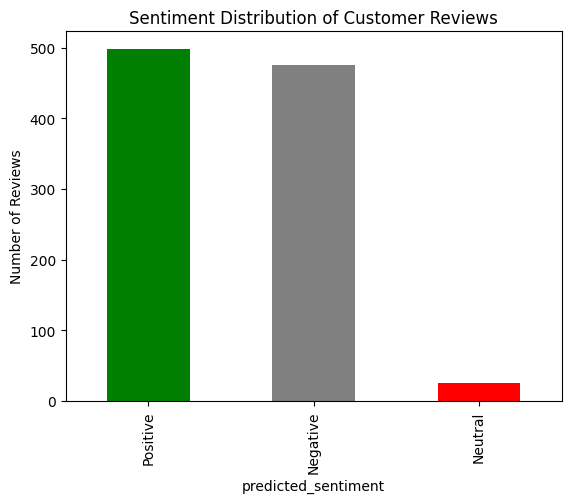

In [42]:
import matplotlib.pyplot as plt

# Plot the distribution of sentiments
df['predicted_sentiment'].value_counts().plot(kind='bar', color=['green', 'gray', 'red'])
plt.title('Sentiment Distribution of Customer Reviews')
plt.ylabel('Number of Reviews')
plt.show()